In [1]:
#Paso 2 — Crear la sesión Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Biblioteca") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/06 23:49:29 WARN Utils: Your hostname, DarkosRace, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/06 23:49:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 23:49:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
#Paso 3 — Crear archivo CSV desde Python

import pandas as pd

datos = {
    "titulo": [
        "Python Básico",
        "SQL Fácil",
        "Big Data Hoy",
        "Machine Learning IA",
        "Redes Informáticas",
        "Power BI Dashboard",
        "Java para Todos",
        "Ciencia de Datos",
        "Python Avanzado",
        "Seguridad Informática"
    ],

    "categoria": [
        "Programación",
        "Bases de Datos",
        "Tecnología",
        "IA",
        "Tecnología",
        "Visualización",
        "Programación",
        "IA",
        "Programación",
        "Seguridad"
    ],

    "paginas": [
        250,
        180,
        320,
        400,
        210,
        150,
        500,
        350,
        600,
        275
    ]
}
df_pandas = pd.DataFrame(datos)

df_pandas.to_csv("libros.csv", index=False)

print("Archivo CSV creado")

Archivo CSV creado


In [3]:
#Paso 4 — Leer CSV con PySpark
df = spark.read.csv(
    "libros.csv",
    header=True,
    inferSchema=True
)

In [13]:
#Paso 5 — Mostrar datos
df.show()

+--------------------+--------------+-------+
|              titulo|     categoria|paginas|
+--------------------+--------------+-------+
|       Python Básico|  Programación|    250|
|           SQL Fácil|Bases de Datos|    180|
|        Big Data Hoy|    Tecnología|    320|
| Machine Learning IA|            IA|    400|
|  Redes Informáticas|    Tecnología|    210|
|  Power BI Dashboard| Visualización|    150|
|     Java para Todos|  Programación|    500|
|    Ciencia de Datos|            IA|    350|
|     Python Avanzado|  Programación|    600|
|Seguridad Informá...|     Seguridad|    275|
+--------------------+--------------+-------+



In [14]:
#Paso 6 — Ver estructura del DataFrame
df.printSchema()

root
 |-- titulo: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- paginas: integer (nullable = true)



In [6]:
#Paso 7 — Seleccionar columnas
df.select("titulo", "paginas").show()

+--------------------+-------+
|              titulo|paginas|
+--------------------+-------+
|       Python Básico|    250|
|           SQL Fácil|    180|
|        Big Data Hoy|    320|
| Machine Learning IA|    400|
|  Redes Informáticas|    210|
|  Power BI Dashboard|    150|
|     Java para Todos|    500|
|    Ciencia de Datos|    350|
|     Python Avanzado|    600|
|Seguridad Informá...|    275|
+--------------------+-------+



In [16]:
#Paso 8 — Filtrar libros con más de 300 páginas
df.filter(df.paginas > 500).show()

+---------------+------------+-------+
|         titulo|   categoria|paginas|
+---------------+------------+-------+
|Python Avanzado|Programación|    600|
+---------------+------------+-------+



In [18]:
#Paso 9 — Ordenar por cantidad de páginas
df.orderBy(df.paginas.asc()).show()

+--------------------+--------------+-------+
|              titulo|     categoria|paginas|
+--------------------+--------------+-------+
|  Power BI Dashboard| Visualización|    150|
|           SQL Fácil|Bases de Datos|    180|
|  Redes Informáticas|    Tecnología|    210|
|       Python Básico|  Programación|    250|
|Seguridad Informá...|     Seguridad|    275|
|        Big Data Hoy|    Tecnología|    320|
|    Ciencia de Datos|            IA|    350|
| Machine Learning IA|            IA|    400|
|     Java para Todos|  Programación|    500|
|     Python Avanzado|  Programación|    600|
+--------------------+--------------+-------+



In [19]:
#Paso 10 — Agrupar por categoría
df.groupBy("categoria").count().show()

+--------------+-----+
|     categoria|count|
+--------------+-----+
|  Programación|    3|
|Bases de Datos|    1|
|            IA|    2|
|    Tecnología|    2|
|     Seguridad|    1|
| Visualización|    1|
+--------------+-----+



In [10]:
#Paso 11 — Promedio de páginas por categoría
from pyspark.sql.functions import avg

df.groupBy("categoria") \
  .agg(avg("paginas").alias("promedio_paginas")) \
  .show()

+--------------+----------------+
|     categoria|promedio_paginas|
+--------------+----------------+
|  Programación|           450.0|
|Bases de Datos|           180.0|
|            IA|           375.0|
|    Tecnología|           265.0|
|     Seguridad|           275.0|
| Visualización|           150.0|
+--------------+----------------+



In [11]:
#Paso 12 — Convertir a Pandas para gráficos
df_pandas = df.toPandas()
print(df_pandas)

                  titulo       categoria  paginas
0          Python Básico    Programación      250
1              SQL Fácil  Bases de Datos      180
2           Big Data Hoy      Tecnología      320
3    Machine Learning IA              IA      400
4     Redes Informáticas      Tecnología      210
5     Power BI Dashboard   Visualización      150
6        Java para Todos    Programación      500
7       Ciencia de Datos              IA      350
8        Python Avanzado    Programación      600
9  Seguridad Informática       Seguridad      275


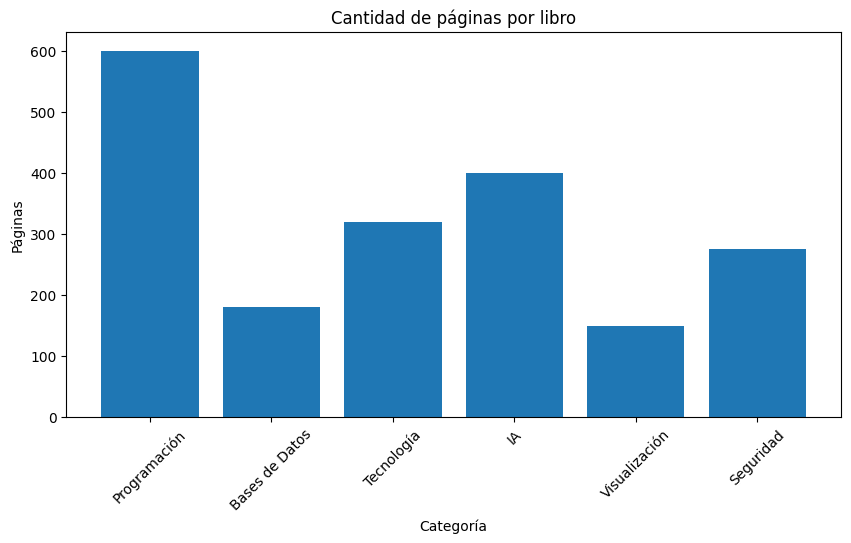

In [20]:
#Paso 13 — Gráfico simple
import matplotlib.pyplot as plt

categorias = df_pandas["categoria"]
paginas = df_pandas["paginas"]

plt.figure(figsize=(10,5))

plt.bar(categorias, paginas)

plt.title("Cantidad de páginas por libro")
plt.xlabel("Categoría")
plt.ylabel("Páginas")

plt.xticks(rotation=45)

plt.show()